# Projeto M1 – Pipeline de Melhoria de Imagens Médicas (MURA)
**Disciplina:** Processamento de Imagens - Prof. Felipe Viel
**Curso:** Ciência da Computação - UNIVALI

**Integrantes:**
- Eduardo José de Souza
- Miguel Pezzini Kuhr
- Nicolas Mendonça Melo Fajardo

## 0. Setup

Imports gerais e funções utilitárias de leitura/exibição de imagens, reaproveitadas do
Projeto M1.1

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from IPython.display import display
from skimage.metrics import peak_signal_noise_ratio, structural_similarity, mean_squared_error

def cv2_imshow(img):
    pass

colab = False
# from google.colab.patches import cv2_imshow

IMG_DIR = 'Imgs'
IMAGES = {
    'img1': f'{IMG_DIR}/image1.png',
    'img2': f'{IMG_DIR}/image2.png',
    'img3': f'{IMG_DIR}/image3.png',
}


def read(img_path, gray=True):
    if gray:
        return cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    return cv2.imread(img_path)


def show(img, nome='Imagem', final=False):
    if img is None:
        print("Imagem nao carregada")
        return
    if colab:
        cv2_imshow(img)
    else:
        cv2.imshow(nome, img)
    if final:
        cv2.waitKey(0)
        cv2.destroyAllWindows()


def show_images(imagens, titulos):  # Mostra mais de uma imagem lado a lado numa mesma janela/plot
    n = len(imagens)
    plt.figure(figsize=(4 * n, 4))
    for i, (img, titulo) in enumerate(zip(imagens, titulos)):
        plt.subplot(1, n, i + 1)
        if img.ndim == 2:
            plt.imshow(img, cmap='gray', vmin=0, vmax=255)
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(titulo)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


def to_uint8(img):
    # Clipa e converte para uint8, necessario depois de qualquer transformacao que saia do range 0-255 ou fique em float
    return np.clip(img, 0, 255).astype(np.uint8)


def histogram(img_gray, bins=256):
    hist = np.zeros(bins, dtype=int)
    for v in img_gray.ravel():
        hist[v] += 1
    return hist


def plot_histogram(img_gray, titulo='Histograma'):
    hist = histogram(img_gray)
    plt.figure()
    plt.bar(range(256), hist, width=1)
    plt.title(titulo)
    plt.xlabel('Intensidade')
    plt.ylabel('Frequencia')
    plt.show()


def pad_image(img, pad):
    return np.pad(img, pad, mode='constant', constant_values=0)


def plot_pipeline_com_histogramas(etapas, nome_img, nome_config, ordem=None, titulos=None):
    """Mostra, para cada etapa do pipeline, a imagem (linha de cima) e o
    histograma correspondente (linha de baixo), lado a lado. Essa e a visao
    que deve ir para o relatorio: permite ver, etapa a etapa, como cada
    operacao (ruido, transformacao pontual, suavizacao, agucamento) muda
    a distribuicao de tons de cinza -- nao so a aparencia da imagem.
    """
    if ordem is None:
        ordem = ['original', 'degradada', 'pontual', 'suavizada', 'final']
    if titulos is None:
        titulos = [f"{nome_img}\nOriginal", "Degradada", "+ Pontual", "+ Suavizada", f"Final\n({nome_config})"]

    n = len(ordem)
    fig, axes = plt.subplots(2, n, figsize=(3.6 * n, 6.5))

    for i, key in enumerate(ordem):
        img = etapas[key]
        ax_img, ax_hist = axes[0, i], axes[1, i]

        ax_img.imshow(img, cmap='gray', vmin=0, vmax=255)
        ax_img.set_title(titulos[i], fontsize=10)
        ax_img.axis('off')

        hist = histogram(img)
        ax_hist.bar(range(256), hist, width=1, color='steelblue')
        ax_hist.set_xlim([0, 255])
        ax_hist.set_xlabel('Intensidade', fontsize=8)
        if i == 0:
            ax_hist.set_ylabel('Frequencia', fontsize=8)
        ax_hist.tick_params(labelsize=7)

    fig.suptitle(f"{nome_img} - {nome_config}: evolucao da imagem e do histograma por etapa", fontsize=11)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def plot_comparacao_histogramas(original, final, nome_img, nome_config):
    """Sobrepoe o histograma da imagem original e da imagem final, para
    comparar visualmente como a distribuicao de tons mudou apos o pipeline
    completo (mais contraste, faixa de tons mais espalhada, etc.).
    """
    hist_o = histogram(original)
    hist_f = histogram(final)

    plt.figure(figsize=(6, 4))
    plt.bar(range(256), hist_o, width=1, alpha=0.5, label='Original', color='gray')
    plt.bar(range(256), hist_f, width=1, alpha=0.5, label='Final', color='firebrick')
    plt.title(f"{nome_img} - Histogramas sobrepostos ({nome_config})")
    plt.xlabel('Intensidade')
    plt.ylabel('Frequencia')
    plt.legend()
    plt.tight_layout()
    plt.show()


def entropy(img):
    """Entropia de Shannon do histograma (em bits). Quanto maior, mais
    'informacao'/detalhe na distribuicao de tons; ruido tende a aumentar
    a entropia, suavizacao tende a reduzi-la.
    """
    hist = histogram(img).astype(np.float64)
    p = hist / hist.sum()
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))


## 1. Seleção e caracterização inicial das imagens

Carrega as 3 radiografias escolhidas (mesma região anatômica do MURA) e exibe cada uma
com seu histograma, para identificar os problemas de qualidade de cada uma (contraste,
ruído, definição) antes de qualquer processamento — conforme pedido no enunciado.

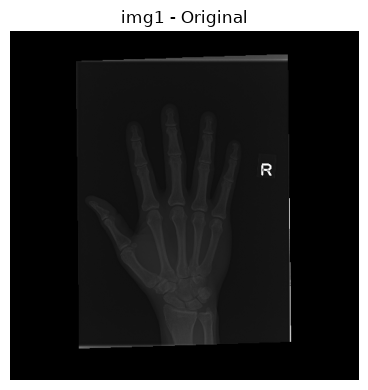

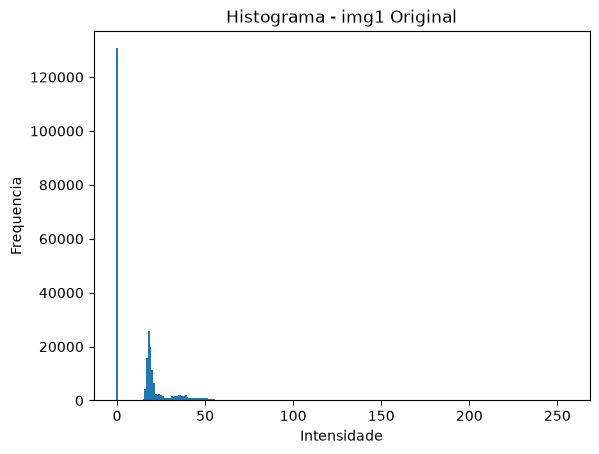

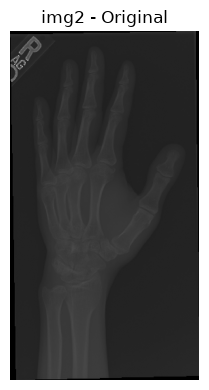

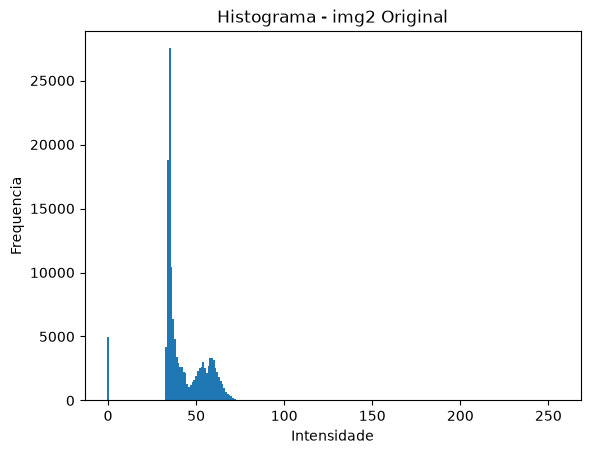

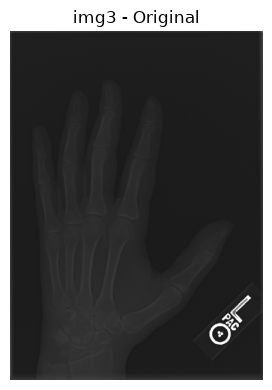

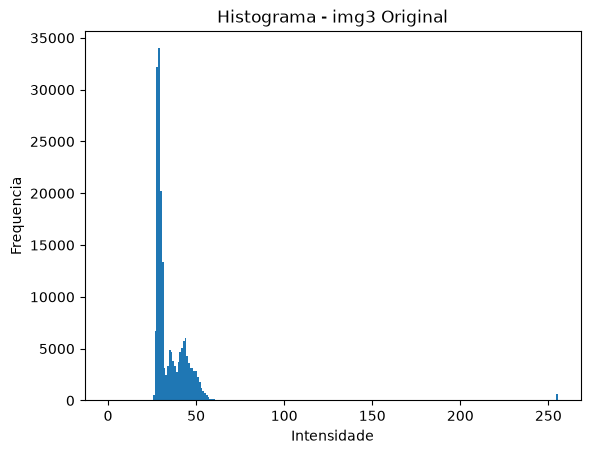

In [ ]:
nomes_imagens = list(IMAGES.keys())
imagens_originais = {nome: read(IMAGES[nome], gray=True) for nome in nomes_imagens}

for nome, img in imagens_originais.items():
    if img is None:
        print(f"[!] Nao foi possivel carregar '{nome}' em {IMAGES[nome]} -- ajustar o caminho.")
        continue
    show_images([img], [f"{nome} - Original"])
    plot_histogram(img, f"Histograma - {nome} Original")

# TODO (texto do relatorio): justificar a escolha da regiao anatomica e das 3 imagens, relacionando cada uma com o problema de qualidade que ela evidencia (contraste, ruido, definicao).

## 2. Inserção de ruído

O enunciado pede que um nível de ruído controlado seja introduzido artificialmente em
cada imagem original, com a intensidade usada devidamente registrada. Duas opções de
ruído são implementadas: **Gaussiano aditivo** e **sal-e-pimenta**. O pipeline abaixo permite escolher qual usar em cada configuração.

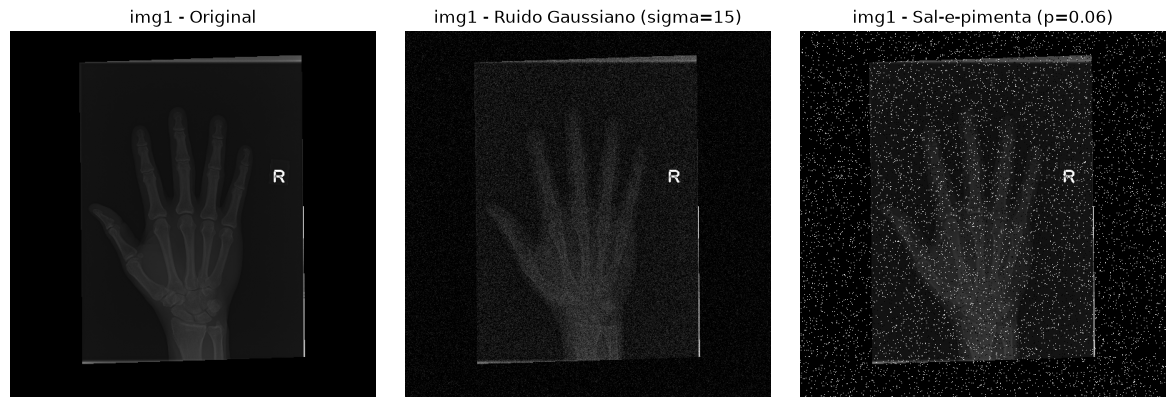

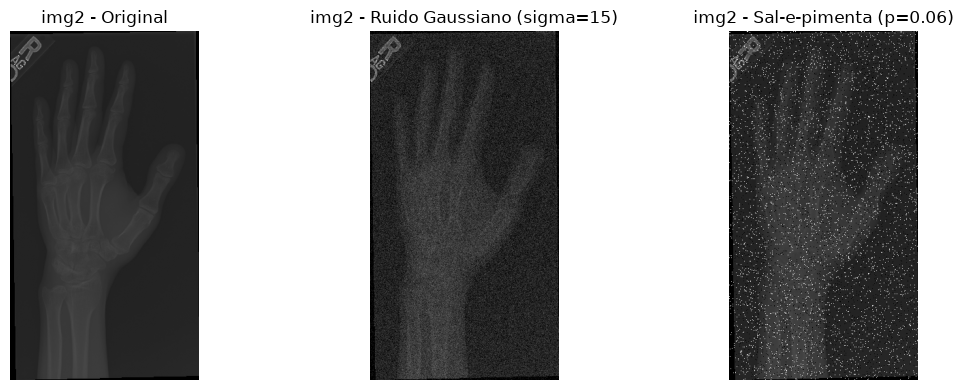

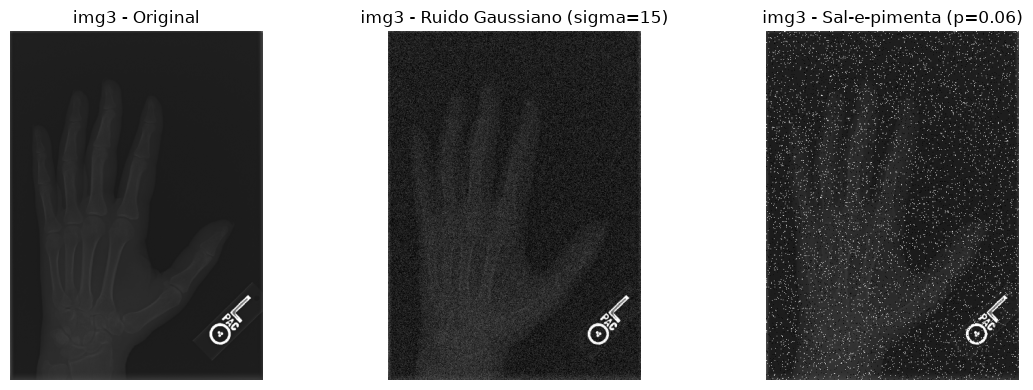

In [ ]:
def gaussian_noise(img, sigma=15, seed=None):
    """Ruido Gaussiano aditivo. sigma controla a intensidade (desvio padrao, em niveis de cinza)."""
    rng = np.random.default_rng(seed)
    ruido = rng.normal(loc=0.0, scale=sigma, size=img.shape)
    saida = img.astype(np.float64) + ruido
    return to_uint8(saida)


def salt_pepper(img, p=0.06, seed=None):
    """Ruido sal-e-pimenta. p e a fracao de pixels afetados (metade vira 0, metade vira 255)."""
    rng = np.random.default_rng(seed)
    saida = img.copy()
    sorteio = rng.random(img.shape)
    saida[sorteio < p / 2] = 0
    saida[sorteio > 1 - p / 2] = 255
    return saida

SIGMA_GAUSSIANO = 15   # TODO: justificar no relatorio
P_SAL_PIMENTA = 0.06

imagens_ruidosas_gauss = {}
imagens_ruidosas_sp = {}

for nome, img in imagens_originais.items():
    if img is None:
        continue
    img_g = gaussian_noise(img, sigma=SIGMA_GAUSSIANO, seed=0)
    img_sp = salt_pepper(img, p=P_SAL_PIMENTA, seed=0)
    imagens_ruidosas_gauss[nome] = img_g
    imagens_ruidosas_sp[nome] = img_sp
    show_images([img, img_g, img_sp], [f"{nome} - Original", f"{nome} - Ruido Gaussiano (sigma={SIGMA_GAUSSIANO})", f"{nome} - Sal-e-pimenta (p={P_SAL_PIMENTA})"])

## 3. Transformação de intensidade (operação pontual)

Duas opções implementadas: **correção gama** e **equalização de histograma**, reaproveitadas
do M1.1. O pipeline escolhe qual usar em cada configuração.

In [15]:
def gamma_correction(img, gamma):
    img_norm = img.astype(np.float64) / 255.0
    s = np.power(img_norm, gamma)
    s = s * 255.0
    return to_uint8(s)


def histEqualization(im):
    hist = histogram(im)
    N = im.size
    cdf = np.cumsum(hist)
    cdf_normalizada = cdf / N
    lut = to_uint8(cdf_normalizada * 255)
    return lut[im]

## 4. Suavização (filtragem espacial — passa-baixas)

`convolve2d` é a convolução manual (reaproveitada do M1.1), usada como base tanto para o
filtro Gaussiano quanto para o Laplaciano/aguçamento mais adiante.

In [17]:
def convolve2d(img, kernel):
    img = img.astype(np.float64)
    kernel = np.array(kernel, dtype=np.float64)
    kh, kw = kernel.shape
    padded = pad_image(img, kh // 2)
    h, w = img.shape
    saida = np.zeros((h, w), dtype=np.float64)

    for i in range(h):
        for j in range(w):
            saida[i, j] = np.sum(padded[i:i+kh, j:j+kw] * kernel)
    return saida


def gaussian_kernel(k, sigma=1.0):
    """Gera um kernel Gaussiano k x k normalizado (soma = 1)."""
    ax = np.arange(k) - (k - 1) / 2.0
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))
    return kernel / kernel.sum()


def gaussian_blur(img, k=5, sigma=1.0):
    kernel = gaussian_kernel(k, sigma)
    saida = convolve2d(img, kernel)
    return to_uint8(saida)


def mediana_do_histograma(hist, mid):
    acc = 0
    for tom in range(256):
        acc += hist[tom]
        if acc > mid:
            return tom
    return 255


def median_filter_optimized(img, k):
    padded = pad_image(img.astype(np.int32), k // 2)
    h, w = img.shape
    saida = np.zeros((h, w), dtype=np.uint8)
    mid = (k * k) // 2

    for i in range(h):
        hist = [0] * 256
        for u in range(k):
            for v in range(k):
                hist[int(padded[i + u, v])] += 1
        saida[i, 0] = mediana_do_histograma(hist, mid)
        for j in range(1, w):
            for u in range(k):
                hist[int(padded[i + u, j - 1])] -= 1
                hist[int(padded[i + u, j + k - 1])] += 1
            saida[i, j] = mediana_do_histograma(hist, mid)
    return saida

## 5. Aguçamento (realce de estruturas)

Laplaciano e Unsharp/High-Boost, reaproveitados do M1.1. O `unsharp_masking` com `k`
ajustável funciona como High-Boost (k=1 é o unsharp "padrão"; k maior intensifica o realce).

In [18]:
kernel_laplaciano = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1],
], dtype=np.float64)

kernel_media = np.ones((3, 3), dtype=np.float64) / 9.0


def laplacian_filter(img):
    return convolve2d(img, kernel_laplaciano)


def sharpen_laplacian(img):
    img = img.astype(np.float64)
    saida = img + laplacian_filter(img)
    return to_uint8(saida)


def unsharp_masking(img, k=1, blur_kernel=None):
    """High-Boost: k=1 e unsharp padrao; k maior realca mais. blur_kernel opcional
    (ex. gaussian_kernel), por padrao usa a media 3x3."""
    img = img.astype(np.float64)
    kernel = blur_kernel if blur_kernel is not None else kernel_media
    borra = convolve2d(img, kernel)
    mascara = img - borra
    saida = img + k * mascara
    return to_uint8(saida), mascara

## 6. Pipeline configurável

Encadeia: **ruído → transformação pontual → suavização → aguçamento**, com cada etapa
parametrizável, para permitir montar diferentes configurações e compará-las.

In [19]:
def pipeline(img, noise_fn, noise_kwargs,
             point_fn, point_kwargs,
             smooth_fn, smooth_kwargs,
             sharpen_fn, sharpen_kwargs):
    """Executa o pipeline completo e retorna um dicionario com cada etapa intermediaria,
    para inspecao visual e para alimentar as metricas depois."""
    etapas = {}
    etapas['original'] = img

    degradada = noise_fn(img, **noise_kwargs)
    etapas['degradada'] = degradada

    pontual = point_fn(degradada, **point_kwargs)
    etapas['pontual'] = pontual

    suavizada = smooth_fn(pontual, **smooth_kwargs)
    etapas['suavizada'] = suavizada

    resultado = sharpen_fn(suavizada, **sharpen_kwargs)
    # unsharp_masking retorna uma tupla (imagem, mascara); os demais retornam so a imagem
    if isinstance(resultado, tuple):
        resultado = resultado[0]
    etapas['final'] = resultado

    return etapas


def mostrar_pipeline(etapas, nome_img, nome_config, mostrar_histogramas=True, mostrar_comparacao=True):
    """Exibe o pipeline completo: imagens lado a lado e, opcionalmente (recomendado
    para o relatorio), a grade imagem+histograma por etapa e o histograma
    sobreposto original x final."""
    show_images(
        [etapas['original'], etapas['degradada'], etapas['pontual'], etapas['suavizada'], etapas['final']],
        [f"{nome_img} - Original", "Degradada", "+ Pontual", "+ Suavizada", f"Final ({nome_config})"],
    )
    if mostrar_histogramas:
        plot_pipeline_com_histogramas(etapas, nome_img, nome_config)
    if mostrar_comparacao:
        plot_comparacao_histogramas(etapas['original'], etapas['final'], nome_img, nome_config)

## 7. Configuração 1

Ruído Gaussiano → correção gama → filtro Gaussiano (suavização) → Laplaciano (aguçamento).

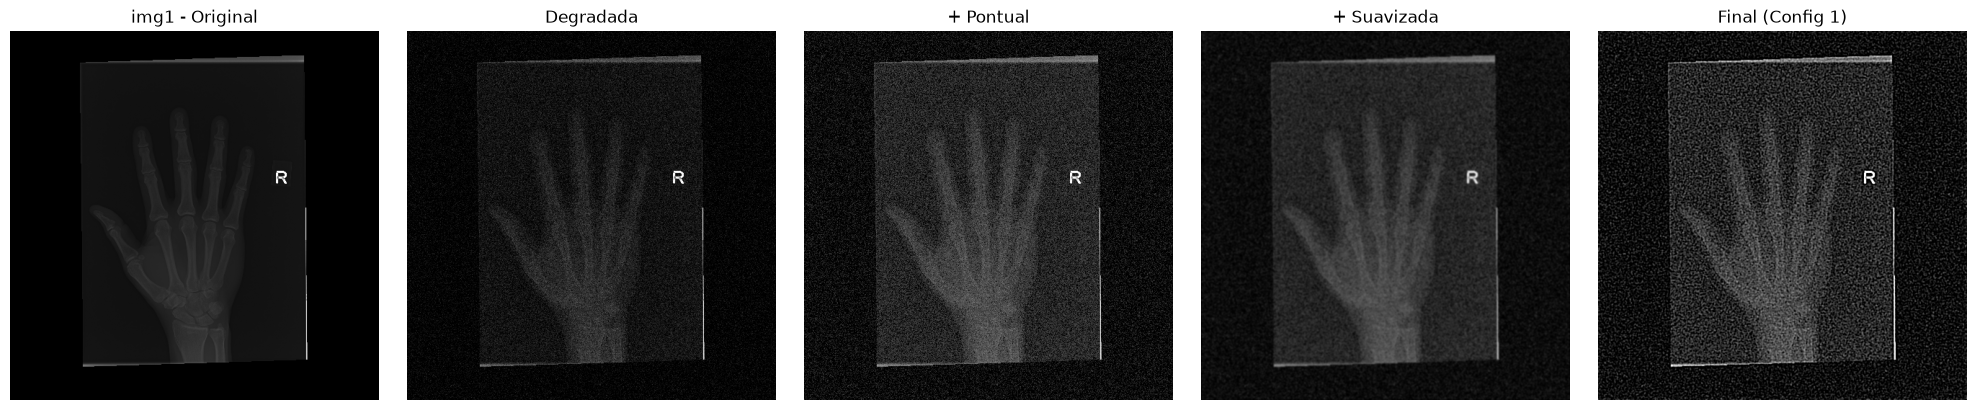

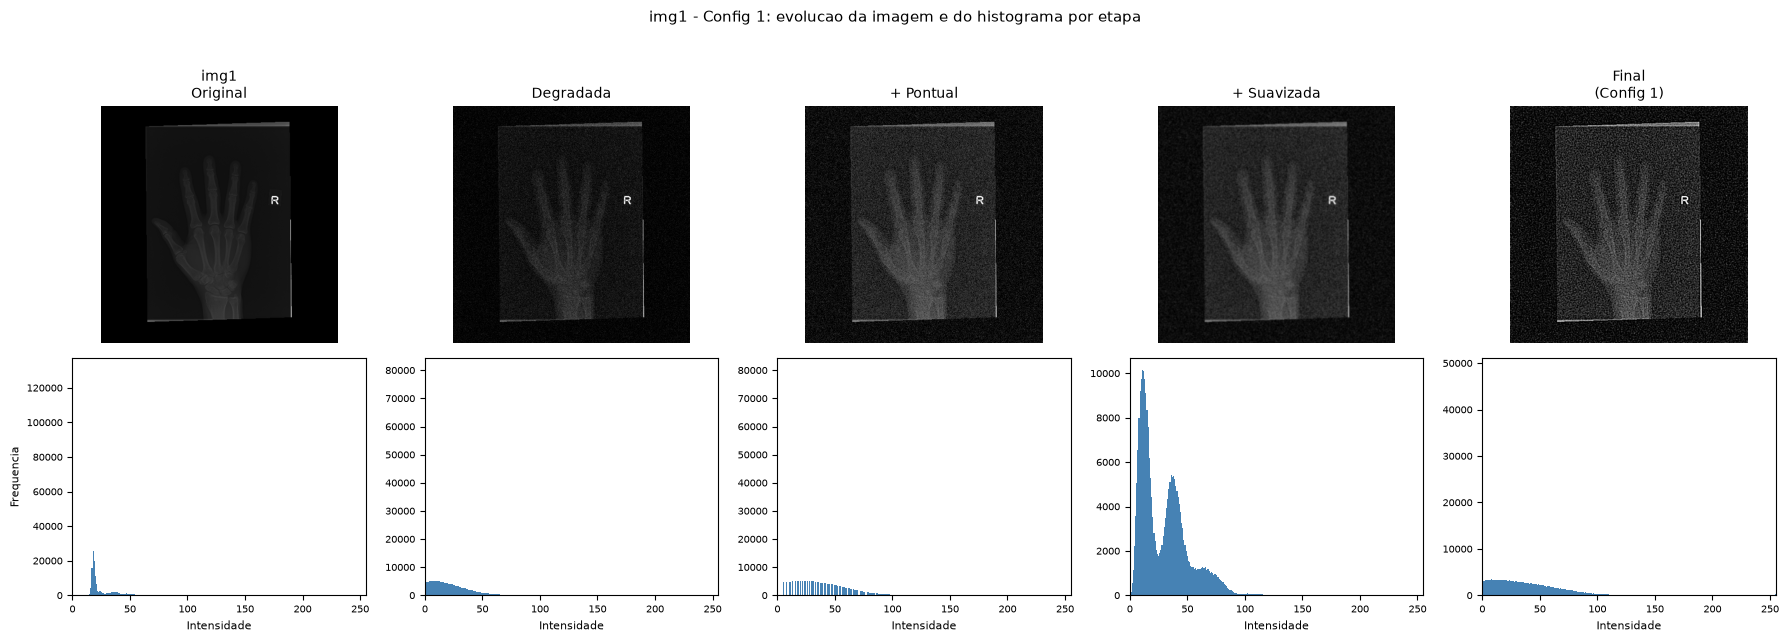

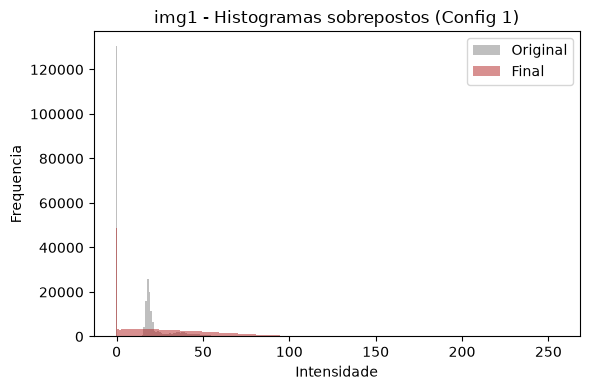

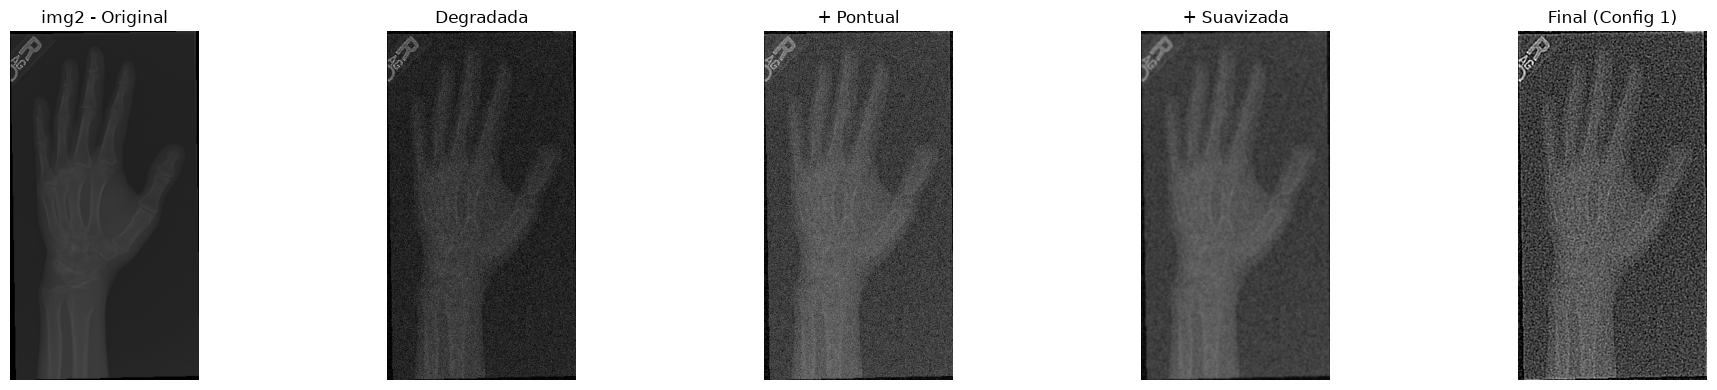

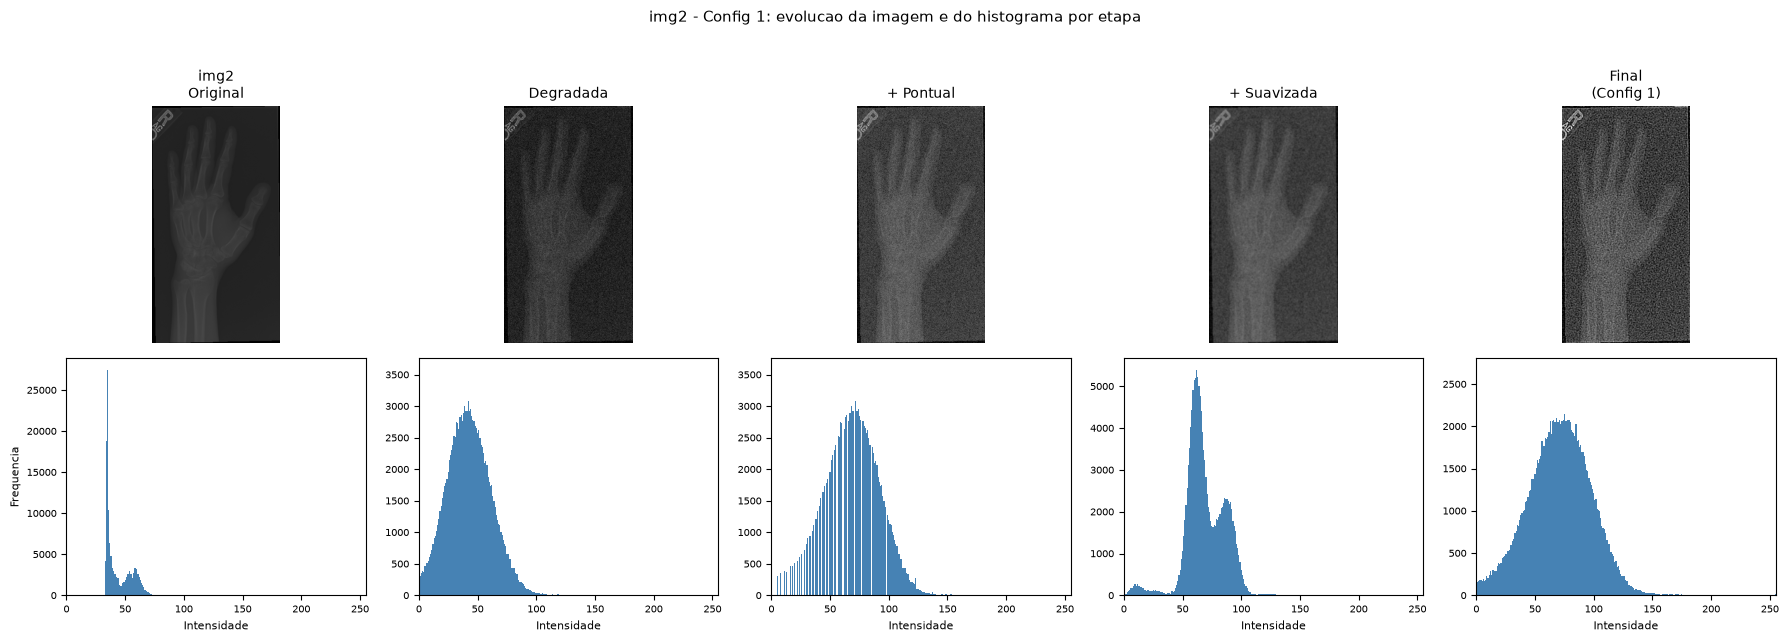

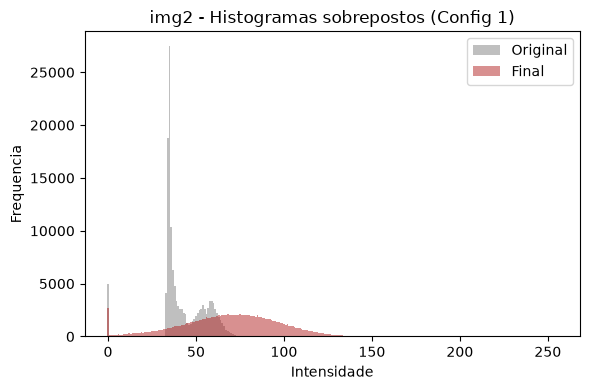

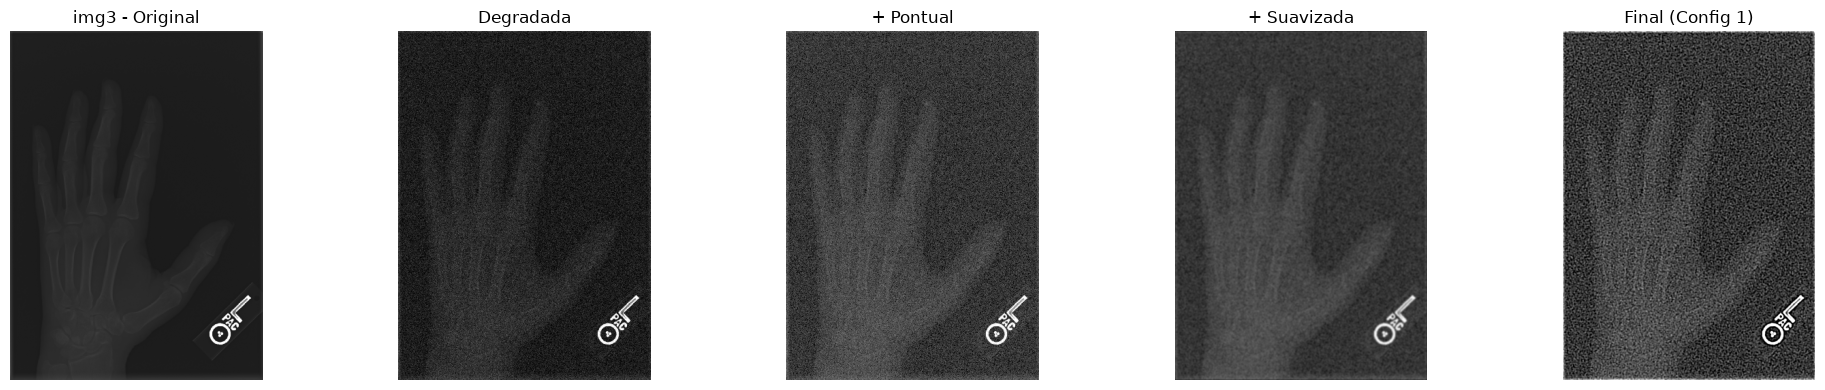

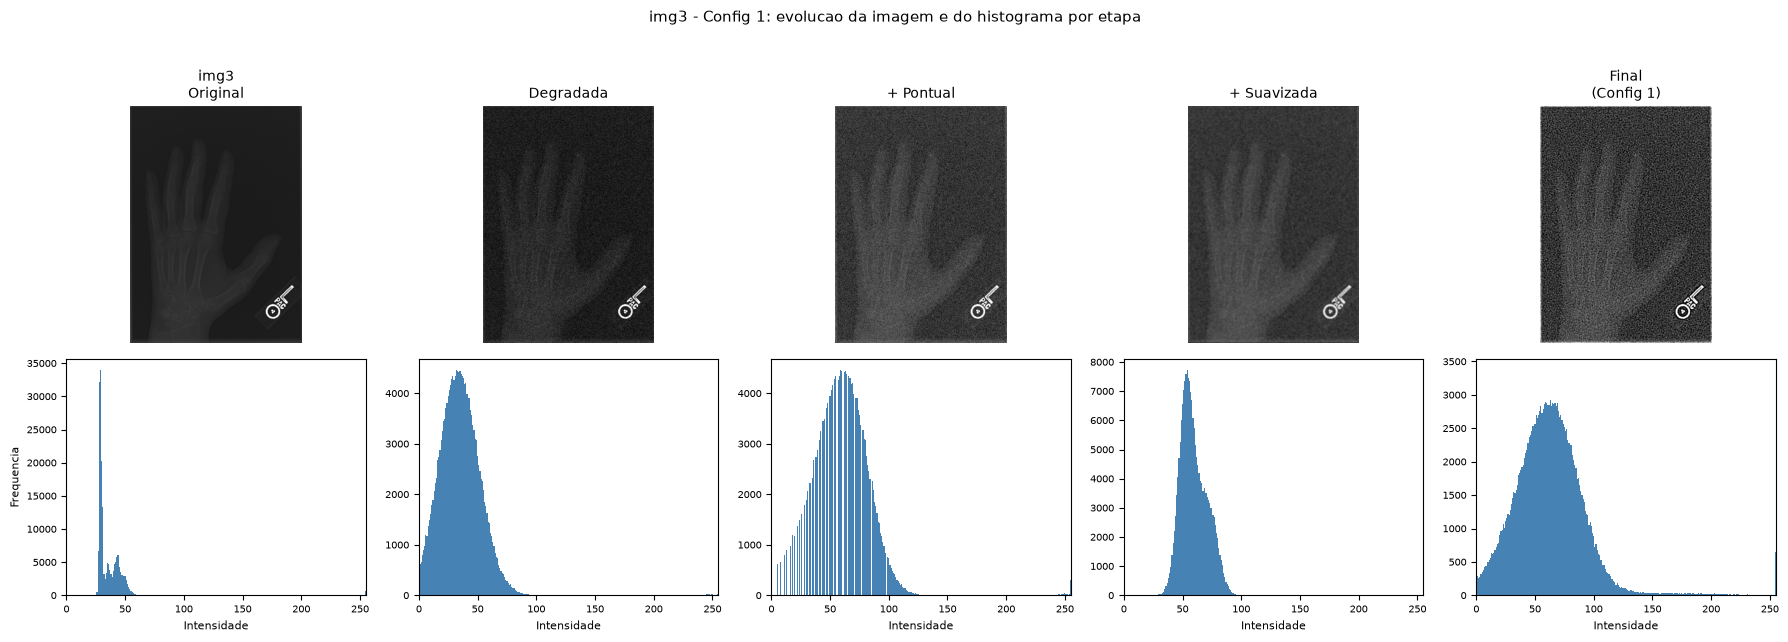

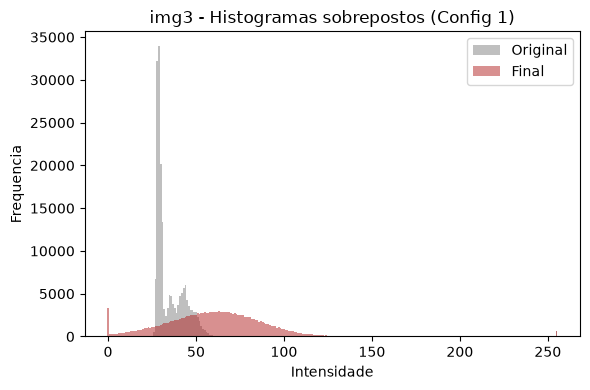

In [20]:
resultados_config1 = {}

for nome, img in imagens_originais.items():
    if img is None:
        continue
    etapas = pipeline(
        img,
        noise_fn=gaussian_noise, noise_kwargs=dict(sigma=SIGMA_GAUSSIANO, seed=0),
        point_fn=gamma_correction, point_kwargs=dict(gamma=0.7),
        smooth_fn=gaussian_blur, smooth_kwargs=dict(k=5, sigma=1.0),
        sharpen_fn=sharpen_laplacian, sharpen_kwargs=dict(),
    )
    resultados_config1[nome] = etapas
    mostrar_pipeline(etapas, nome, "Config 1")

## 8. Configuração 2

Ruído sal-e-pimenta → equalização de histograma → filtro de mediana (suavização) →
High-Boost/unsharp (aguçamento). Muda a técnica em cada etapa em relação à Config 1,
conforme pedido no enunciado (pelo menos duas configurações diferentes).

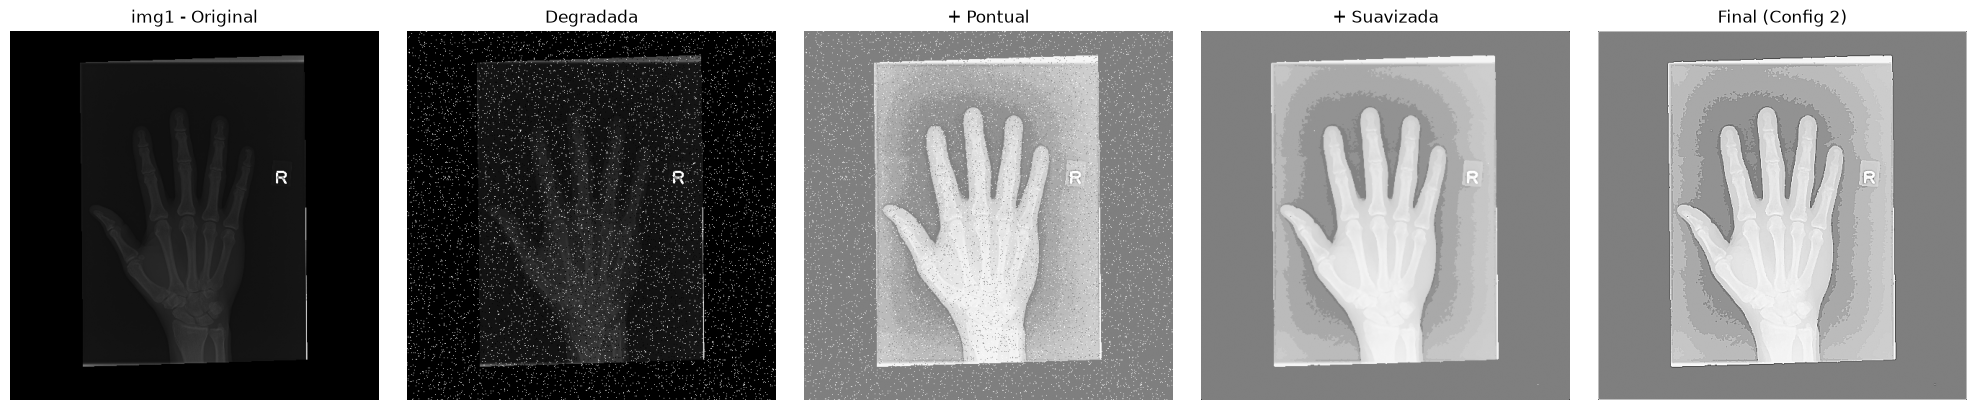

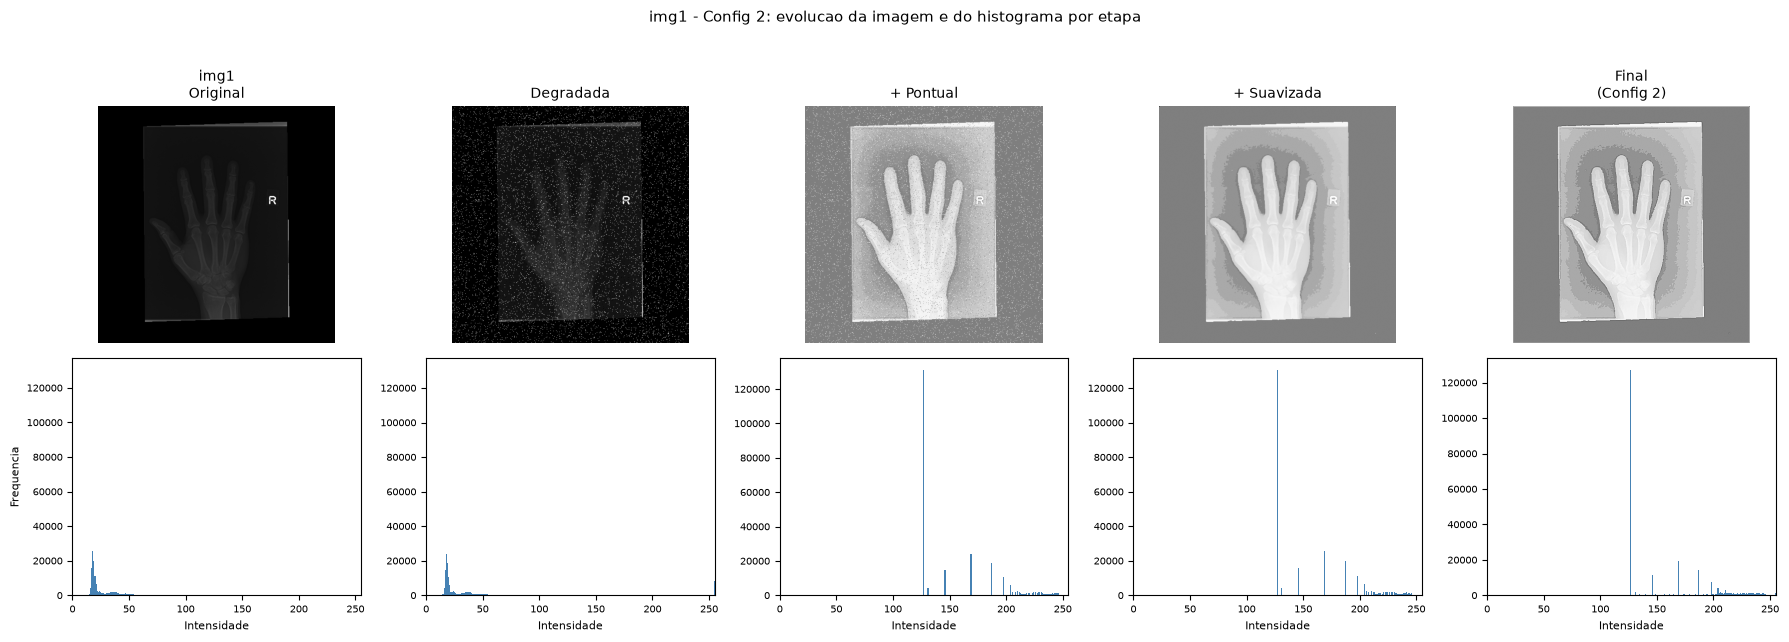

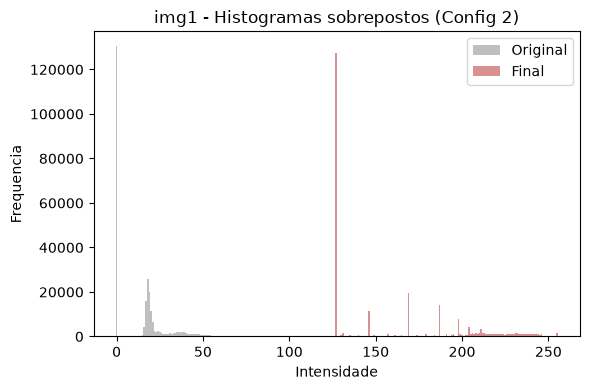

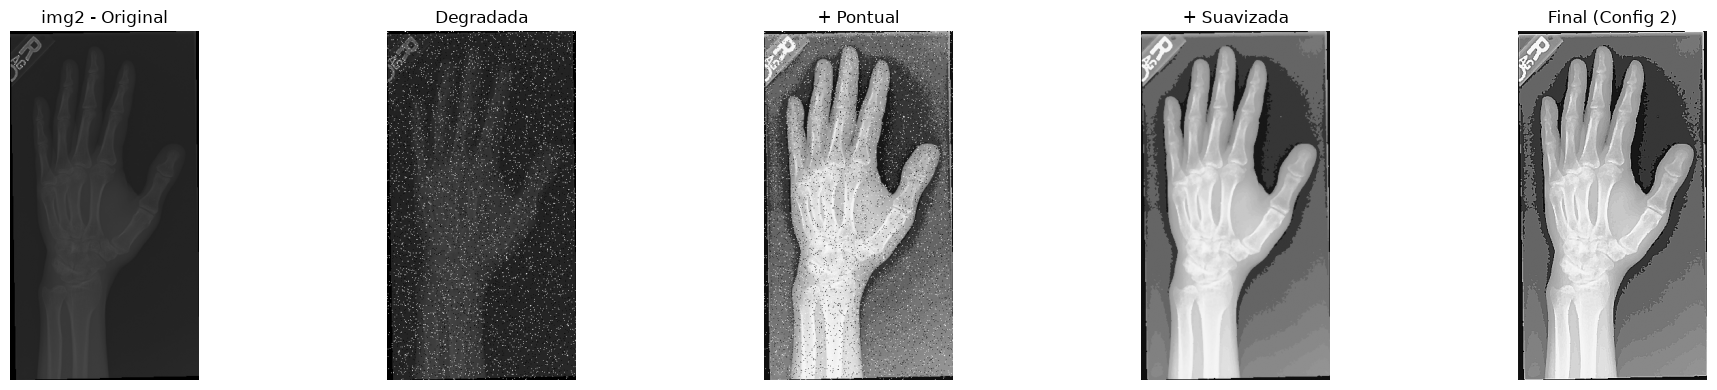

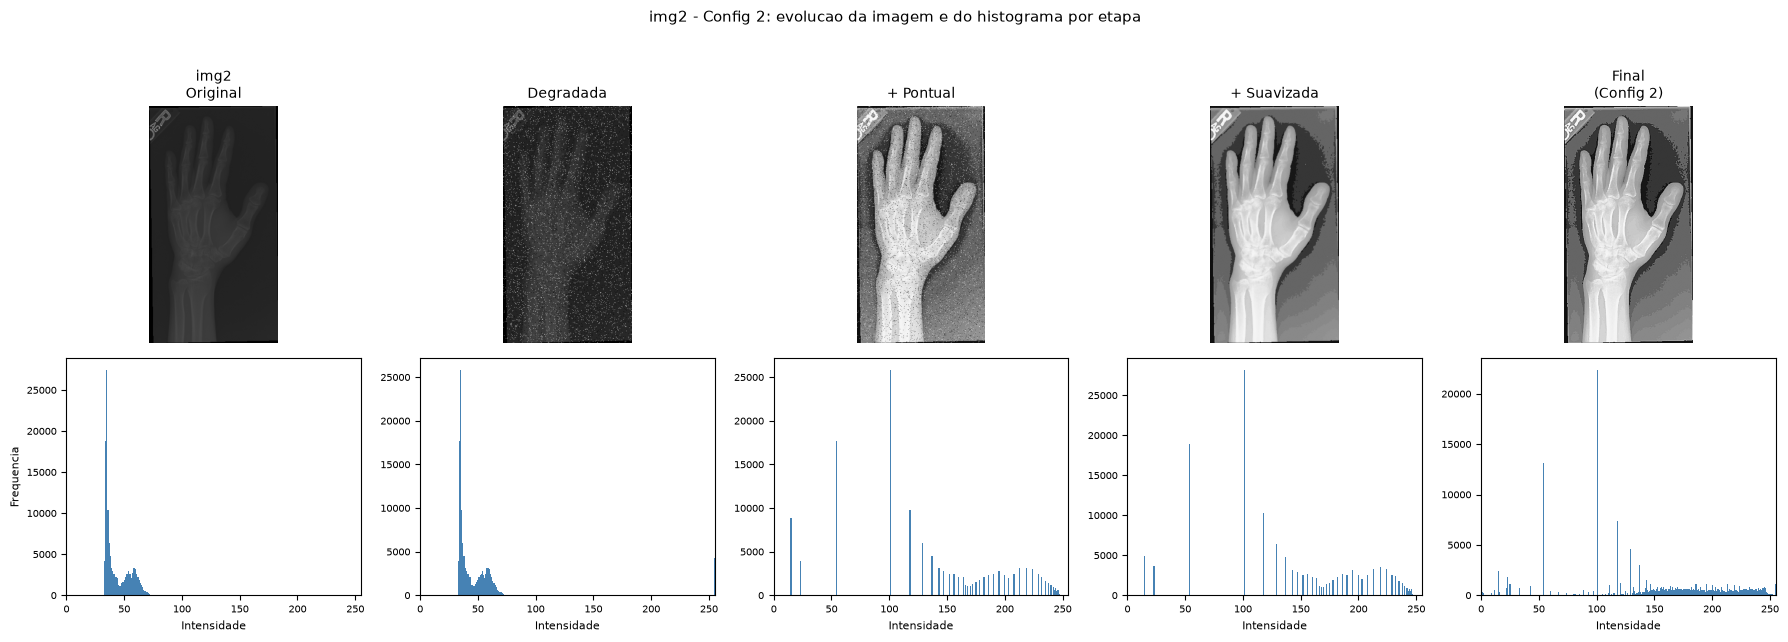

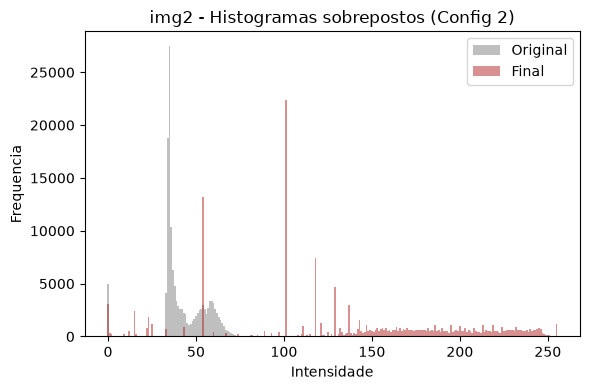

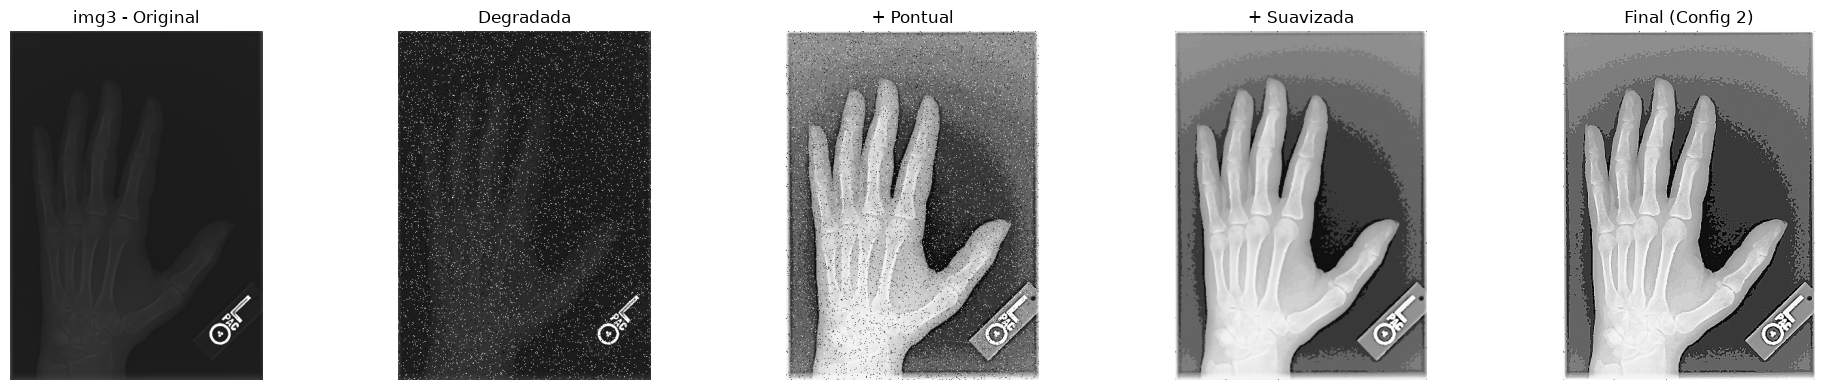

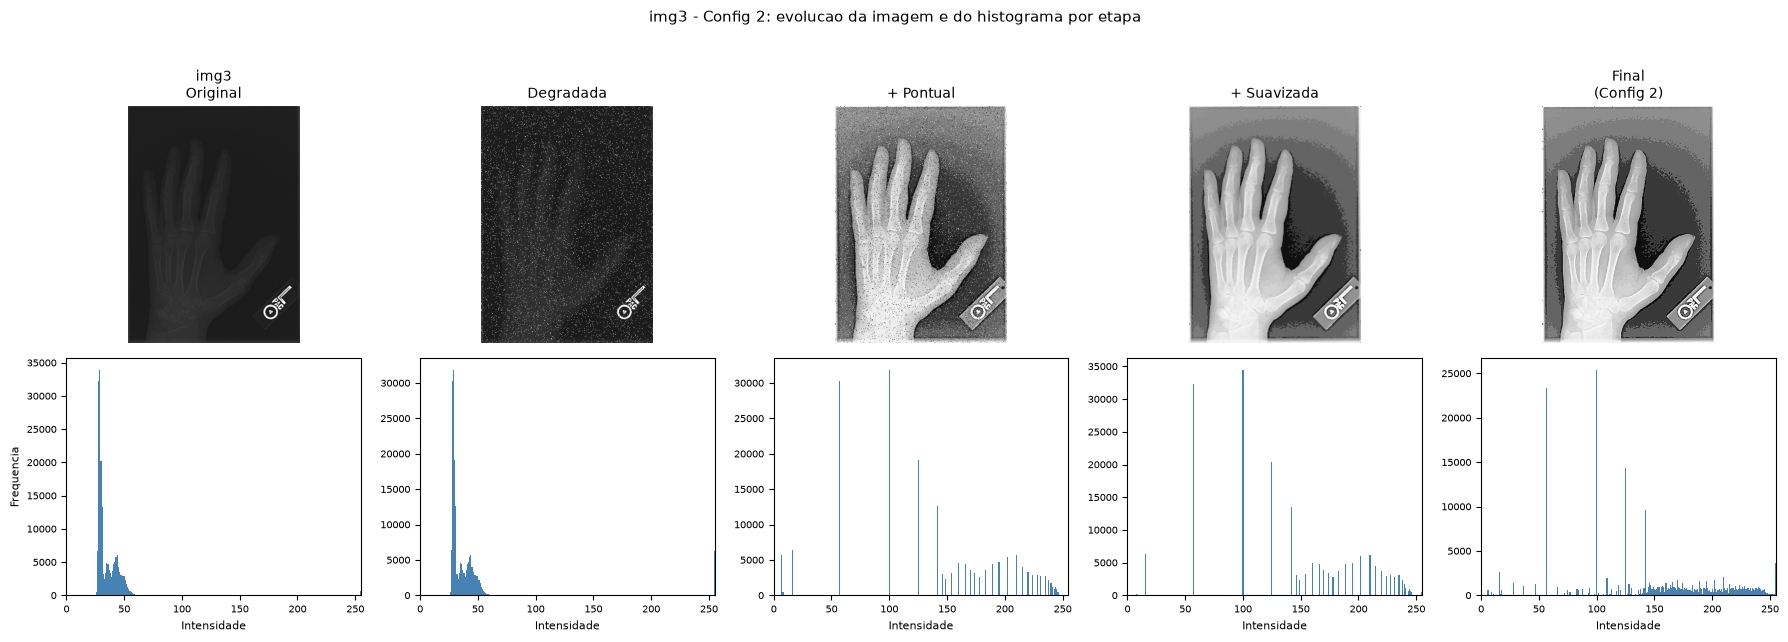

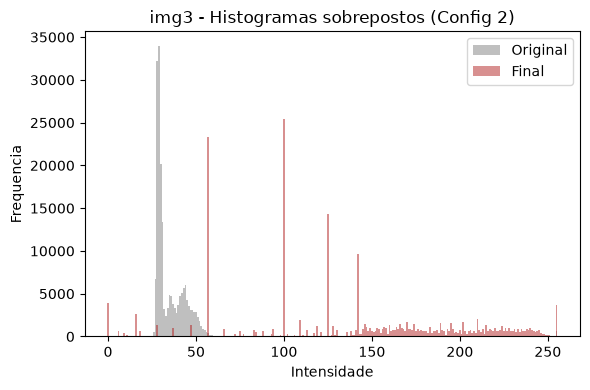

In [21]:
resultados_config2 = {}

for nome, img in imagens_originais.items():
    if img is None:
        continue
    etapas = pipeline(
        img,
        noise_fn=salt_pepper, noise_kwargs=dict(p=P_SAL_PIMENTA, seed=0),
        point_fn=histEqualization, point_kwargs=dict(),
        smooth_fn=median_filter_optimized, smooth_kwargs=dict(k=3),
        sharpen_fn=unsharp_masking, sharpen_kwargs=dict(k=2),
    )
    resultados_config2[nome] = etapas
    mostrar_pipeline(etapas, nome, "Config 2")

## 9. Métricas quantitativas

Para cada imagem, comparamos `original` × `degradada` × `resultados_config1[nome]['final']` ×
`resultados_config2[nome]['final']` usando **PSNR**, **SSIM** e **RMSE** (todas medindo
fidelidade em relação à original). A tabela final resume os resultados por imagem e por
etapa, e é a peça central para discutir no relatório qual configuração funcionou melhor em
cada caso.

In [ ]:
def calcular_metricas(img_a, img_b):
    """Compara img_b em relacao a img_a (referencia). Retorna PSNR, SSIM (fidelidade
    a original) e RMSE (erro medio, em niveis de cinza; quanto menor mais proxima da original)."""
    psnr = peak_signal_noise_ratio(img_a, img_b, data_range=255)
    ssim = structural_similarity(img_a, img_b, data_range=255)
    rmse = np.sqrt(mean_squared_error(img_a, img_b))
    return {'PSNR': psnr, 'SSIM': ssim, 'RMSE': rmse}


# Descricao curta de cada etapa, para deixar explicito no relatorio qual tecnica
PIPELINE_DESCRICOES = {
    'Degradada (ruido gaussiano)': f'Ruido Gaussiano (sigma={SIGMA_GAUSSIANO})',
    'Degradada (sal-e-pimenta)': f'Sal-e-pimenta (p={P_SAL_PIMENTA})',
    'Config 1 - Final': 'Gaussiano -> Gama -> Blur Gaussiano -> Laplaciano',
    'Config 2 - Final': 'Sal-e-pimenta -> Equalizacao -> Mediana -> Unsharp (k=2)',
}

linhas = []
for nome in imagens_originais:
    if imagens_originais[nome] is None:
        continue
    original = resultados_config1[nome]['original']
    degradada = resultados_config1[nome]['degradada']  # ruido usado na Config 1 (Gaussiano)
    degradada_c2 = resultados_config2[nome]['degradada']  # ruido usado na Config 2 (sal-e-pimenta)
    final1 = resultados_config1[nome]['final']
    final2 = resultados_config2[nome]['final']

    for etapa_nome, img_etapa in [
        ('Degradada (ruido gaussiano)', degradada),
        ('Degradada (sal-e-pimenta)', degradada_c2),
        ('Config 1 - Final', final1),
        ('Config 2 - Final', final2),
    ]:
        m = calcular_metricas(original, img_etapa)
        linhas.append({
            'Imagem': nome,
            'Etapa': etapa_nome,
            'Pipeline': PIPELINE_DESCRICOES[etapa_nome],
            'PSNR (dB)': round(m['PSNR'], 2),
            'SSIM': round(m['SSIM'], 4),
            'RMSE': round(m['RMSE'], 2),
        })

tabela_metricas = pd.DataFrame(linhas)
display(tabela_metricas)

# TODO (texto do relatorio): comentar, por imagem, qual configuracao teve o melhor PSNR/SSIM (maiores = mais proxima da original) e RMSE (menor = mais proxima da original), relacionando com a inspecao visual feita na Secao 1.

,Imagem,Etapa,Pipeline,PSNR (dB),SSIM,RMSE
0,img1,Degradada (ruido gaussiano),Ruido Gaussiano (sigma=15),26.33,0.2023,12.30
1,img1,Degradada (sal-e-pimenta),Sal-e-pimenta (p=0.06),15.64,0.2324,42.12
2,img1,Config 1 - Final,Gaussiano -> Gama -> Blur Gaussiano -> Laplaciano,18.90,0.0767,28.93
3,img1,Config 2 - Final,Sal-e-pimenta -> Equalizacao -> Mediana -> Uns...,4.61,0.0917,149.90
4,img2,Degradada (ruido gaussiano),Ruido Gaussiano (sigma=15),24.73,0.2594,14.80
5,img2,Degradada (sal-e-pimenta),Sal-e-pimenta (p=0.06),16.62,0.1904,37.64
6,img2,Config 1 - Final,Gaussiano -> Gama -> Blur Gaussiano -> Laplaciano,17.09,0.1467,35.64
7,img2,Config 2 - Final,Sal-e-pimenta -> Equalizacao -> Mediana -> Uns...,7.38,0.3311,109.01
8,img3,Degradada (ruido gaussiano),Ruido Gaussiano (sigma=15),24.74,0.2430,14.78
9,img3,Degradada (sal-e-pimenta),Sal-e-pimenta (p=0.06),16.41,0.1996,38.53
